# Bloque 3: Análisis de Disparidad Interna y Eficiencia por Sedes Universitarias

Este proyecto es la tercera y útima parte de una serie de tres análisis independientes sobre el rendimiento en la selectividad española. El objetivo de este es desglosar los resultados de la PAU 2026 en Andalucía por sedes universitarias para evaluar si el rendimiento es homogéneo dentro de una misma región o si la escala de la institución influye en el éxito de los estudiantes. 

Con este enfoque busco comprobar si las diferencias internas son tan significativas como las brechas autonómicas, aportando una perspectiva basada en datos al debate del Distrito Único.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Carga del dataset original
df = pd.read_excel("portfolio_pau_2025_2026.xlsx", sheet_name="sedes_andalucia_2026")

# Limpieza del formato en la columna de porcentajes
if df['porcentaje_aprobados'].dtype == 'object':
    df['porcentaje_aprobados'] = df['porcentaje_aprobados'].str.rstrip('%').str.replace(',', '.').astype('float')

# Cálculo de impacto absoluto
df['alumnos_suspendidos'] = df['presentados'] - df['aprobados']
df['peso_sobre_total_pct'] = (df['presentados'] / df['presentados'].sum()) * 100 #porcentaje del total de alumnos
# de toda Andalucía que se ha examinado en esa universidad.

# Ordenar para estructurar el ranking de rendimiento relativo
df_ordenado = df.sort_values(by="porcentaje_aprobados", ascending=False)
print(df_ordenado)

                    universidad  presentados  aprobados  porcentaje_aprobados  \
5           Universidad de Jaén         2844       2674                 94.02   
6         Universidad de Málaga         7836       7150                 91.25   
0        Universidad de Almería         3379       3079                 91.12   
2        Universidad de Córdoba         3729       3396                 91.07   
8        Universidad de Sevilla         9262       8399                 90.68   
3        Universidad de Granada         5610       5078                 90.52   
7  Universidad Pablo de Olavide         1372       1237                 90.16   
1          Universidad de Cádiz         5942       5303                 89.25   
4         Universidad de Huelva         2019       1742                 86.28   

   alumnos_suspendidos  peso_sobre_total_pct  
5                  170              6.772557  
6                  686             18.660253  
0                  300              8.046579  
2

## 1. Análisis de Rendimiento Relativo: Ranking de Aprobados

La primera aproximación consiste en evaluar el porcentaje de éxito de cada universidad de forma aislada. Esto nos permite ver los extremos de la convocatoria y medir la brecha máxima de aprobados dentro del mismo territorio.

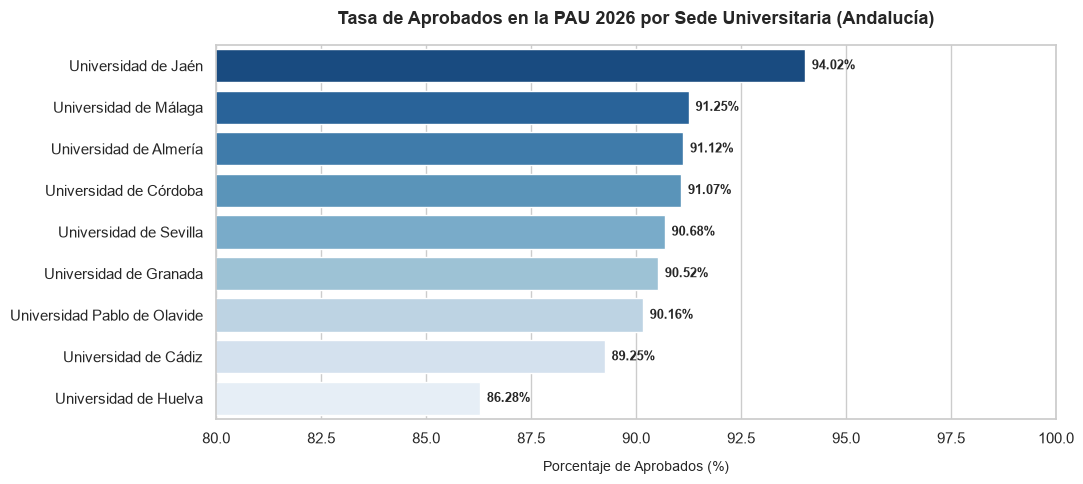

DATOS CLAVE DE RENDIMIENTO RELATIVO:
- Máximo rendimiento: Universidad de Jaén (94.02%).
- Mínimo rendimiento: Universidad de Huelva (86.28%).
- Brecha observada: 7.74 puntos porcentuales de diferencia en la misma región.


In [23]:
plt.figure(figsize=(11, 5))

ax1 = sns.barplot(
    data=df_ordenado, 
    x="porcentaje_aprobados", 
    y="universidad", 
    hue="universidad", 
    palette="Blues_r", 
    legend=False
)

plt.title("Tasa de Aprobados en la PAU 2026 por Sede Universitaria (Andalucía)", fontsize=13, pad=15, weight='bold')
plt.xlabel("Porcentaje de Aprobados (%)", fontsize=10, labelpad=10)
plt.ylabel("") 
plt.xlim(80, 100) 

# Etiquetas con el valor en cada barra
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f"{width:.2f}%", 
                (width, p.get_y() + p.get_height() / 2.), 
                va='center', ha='left',
                xytext=(5, 0), 
                textcoords='offset points', 
                fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

# Datos clave de rendimiento relativo
top_sede = df_ordenado.iloc[0]
bottom_sede = df_ordenado.iloc[-1]
brecha_interna = top_sede['porcentaje_aprobados'] - bottom_sede['porcentaje_aprobados']

print(f"DATOS CLAVE DE RENDIMIENTO RELATIVO:")
print(f"- Máximo rendimiento: {top_sede['universidad']} ({top_sede['porcentaje_aprobados']:.2f}%).")
print(f"- Mínimo rendimiento: {bottom_sede['universidad']} ({bottom_sede['porcentaje_aprobados']:.2f}%).")
print(f"- Brecha observada: {brecha_interna:.2f} puntos porcentuales de diferencia en la misma región.")

## 2. Dimensión del Distrito: Presentados vs. Aprobados en Valores Absolutos

Para evitar el sesgo de mirar solo porcentajes, incorporamos una visualización que compara el volumen real de alumnos presentados frente a los que consiguen aprobar. Esto expone visualmente el tamaño cada sede.

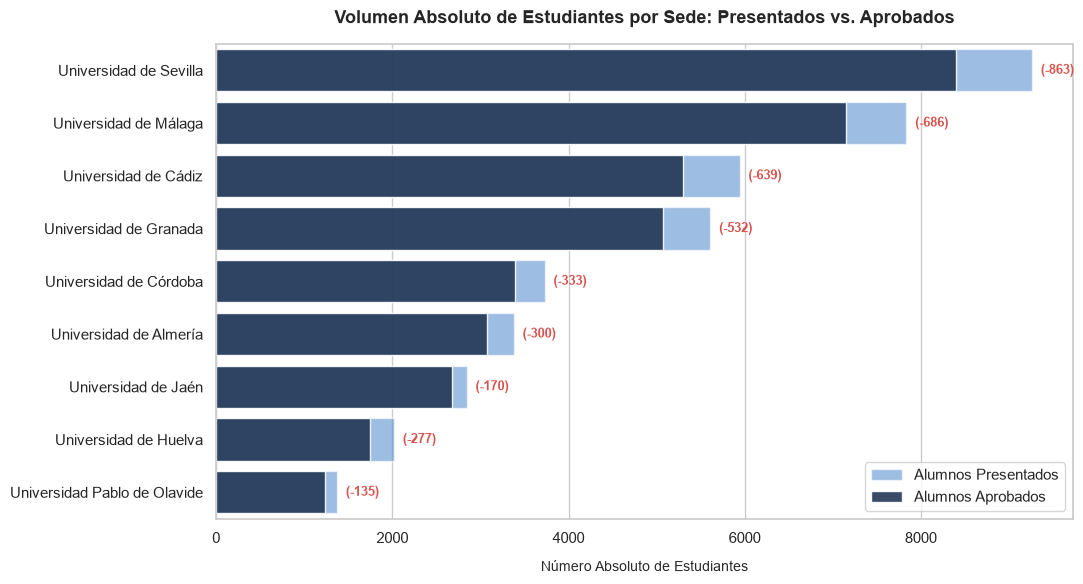

In [10]:
# Reestructuramos el dataframe para ordenar las universidades por volumen de alumnos presentados
df_volumen = df.sort_values(by="presentados", ascending=False)

plt.figure(figsize=(11, 6))

# Dibujamos primero la barra de alumnos presentados (Total)
sns.barplot(
    data=df_volumen,
    x="presentados",
    y="universidad",
    color="#4A90E2",
    alpha=0.6,
    label="Alumnos Presentados"
)

# Añadirmos la barra de alumnos aprobados (Éxito)
sns.barplot(
    data=df_volumen,
    x="aprobados",
    y="universidad",
    color="#1B365D",
    alpha=0.9,
    label="Alumnos Aprobados"
)

plt.title("Volumen Absoluto de Estudiantes por Sede: Presentados vs. Aprobados", fontsize=13, pad=15, weight='bold')
plt.xlabel("Número Absoluto de Estudiantes", fontsize=10, labelpad=10)
plt.ylabel("")
plt.legend(loc="lower right", frameon=True)

# Añadimos los valores numéricos de los suspendidos
for i, p in enumerate(plt.gca().patches[9:]): # Nos enfocamos en las barras de aprobados para calcular el extremo
    width_aprobados = p.get_width()
    width_presentados = df_volumen['presentados'].iloc[i]
    suspendidos = df_volumen['alumnos_suspendidos'].iloc[i]
    
    plt.text(
        x=width_presentados + 100,
        y=p.get_y() + p.get_height() / 2.,
        s=f"(-{suspendidos})",
        va='center', ha='left',
        fontsize=9, color='#d9534f', weight='bold'
    )

plt.tight_layout()
plt.show()

## 3. Relación entre el tamaño de la universidad y su tasa de aprobados

Aquí cruzo el número de alumnos presentados con el porcentaje de aprobados para ver si las universidades más grandes tienen peor o mejor rendimiento. 

Uso las medianas (las líneas discontinuas) para dividir el gráfico en cuatro zonas y ver rápido dónde se sitúa cada una. Además, el tamaño de cada burbuja depende de los alumnos que han suspendido: cuanto más grande es la burbuja, más alumnos se han quedado fuera. Esto ayuda a ver focos que el porcentaje por sí solo no muestra.

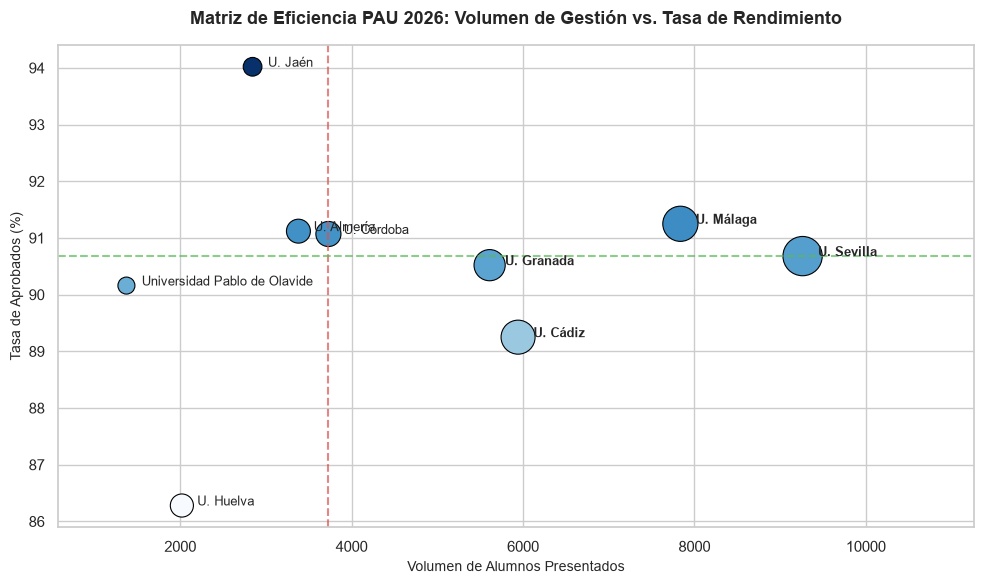

In [13]:
plt.figure(figsize=(10, 6))

# Gráfico de dispersión cruzando volumen, tasa y número de suspensos (tamaño)
ax_scatter = sns.scatterplot(
    data=df,
    x="presentados",
    y="porcentaje_aprobados",
    size="alumnos_suspendidos",
    sizes=(150, 800),
    hue="porcentaje_aprobados",
    palette="Blues",
    edgecolor="black",
    linewidth=0.8,
    legend=False
)

# Definición de medianas para construir los cuadrantes operativos
mediana_presentados = df['presentados'].median()
mediana_rendimiento = df['porcentaje_aprobados'].median()

plt.axvline(mediana_presentados, color='#d9534f', linestyle='--', alpha=0.7)
plt.axhline(mediana_rendimiento, color='#5cb85c', linestyle='--', alpha=0.7)

# Etiquetamos de manera que no se solapen
for i in range(df.shape[0]):
    nombre_universidad = df.universidad.iloc[i].replace("Universidad de ", "U. ")
    alumnos_suspendidos = df.alumnos_suspendidos.iloc[i]
    
    # Resaltamos visualmente las sedes con mayor volumen de suspensos reales
    es_critico = alumnos_suspendidos > 400
    
    plt.text(
        x=df.presentados.iloc[i] + 180, 
        y=df.porcentaje_aprobados.iloc[i], 
        s=nombre_universidad,
        fontsize=9,
        weight='bold' if es_critico else 'normal'
    )

plt.title("Matriz de Eficiencia PAU 2026: Volumen de Gestión vs. Tasa de Rendimiento", fontsize=13, pad=15, weight='bold')
plt.xlabel("Volumen de Alumnos Presentados", fontsize=10)
plt.ylabel("Tasa de Aprobados (%)", fontsize=10)
plt.xlim(df['presentados'].min() - 800, df['presentados'].max() + 2000)

plt.tight_layout()
plt.show()

## 4. Conclusiones finales

En esta sección se contrastan los datos relativos frente a los absolutos. El objetivo es evaluar el impacto real en número de estudiantes afectados por cada sede y aportar una conclusión fundamentada sobre la disparidad del sistema.

In [22]:
impacto_total_andaluz = df['alumnos_suspendidos'].sum()
foco_critico = df.sort_values(by="alumnos_suspendidos", ascending=False).iloc[0]

print(f"CONCLUSIONES DEL PROYECTO 3:")
print(f"===========================================================")
print(f"- Volumen total: En total se han examinado {df['presentados'].sum():,} alumnos en Andalucía.")
print(f"- Alumnos suspensos: De todos ellos, {impacto_total_andaluz:,} estudiantes no han conseguido pasar la prueba.")
print(f"- El peso de las universidades grandes: El caso más claro es la {foco_critico['universidad']}.")
print(f"  Aunque tiene un porcentaje de aprobados bastante alto ({foco_critico['porcentaje_aprobados']:.2f}%), al gestionar a tantísima gente")
print(f"  es la sede donde más alumnos suspenden en total: {foco_critico['alumnos_suspendidos']} personas se quedan fuera aquí.")
print(f"- Puntos clave del análisis:")
print(f"  1. Las universidades más pequeñas (como Jaén o Almería) consiguen porcentajes de éxito más altos.")
print(f"     Esto puede deberse a un nivel de preparación diferente o a una menor ratio de alumnos por aula,")
print(f"     lo que permite una atención más individualizada en los institutos de esas zonas.")
print(f"  2. Las provincias con más población (Sevilla o Málaga) concentran el mayor volumen de alumnos")
print(f"     y, por tanto, acumulan la gran mayoría de los suspensos reales de la comunidad.")
print(f"  3. Veredicto final: Hay casi un 8% de diferencia en los aprobados según la universidad donde te examines.")
print(f"     Como en Andalucía el examen es exactamente el mismo para todos, esta brecha demuestra que el éxito")
print(f"     no depende solo de la prueba en sí, sino del nivel de preparación final de los estudiantes. Factores como")
print(f"     las ratios por aula, la atención individualizada o el contexto socioeconómico marcan la diferencia,")
print(f"     lo que evidencia que un examen único no garantiza resultados homogéneos si las condiciones de fondo")
print(f"     y la preparación previa son distintas.")

CONCLUSIONES DEL PROYECTO 3:
- Volumen total: En total se han examinado 41,993 alumnos en Andalucía.
- Alumnos suspensos: De todos ellos, 3,935 estudiantes no han conseguido pasar la prueba.
- El peso de las universidades grandes: El caso más claro es la Universidad de Sevilla.
  Aunque tiene un porcentaje de aprobados bastante alto (90.68%), al gestionar a tantísima gente
  es la sede donde más alumnos suspenden en total: 863 personas se quedan fuera aquí.
- Puntos clave del análisis:
  1. Las universidades más pequeñas (como Jaén o Almería) consiguen porcentajes de éxito más altos.
     Esto puede deberse a un nivel de preparación diferente o a una menor ratio de alumnos por aula,
     lo que permite una atención más individualizada en los institutos de esas zonas.
  2. Las provincias con más población (Sevilla o Málaga) concentran el mayor volumen de alumnos
     y, por tanto, acumulan la gran mayoría de los suspensos reales de la comunidad.
  3. Veredicto final: Hay casi un 8% de d